In [265]:
device = "cuda"

In [266]:
import torch
torch.cuda.is_available()

True

In [267]:
import numpy as np 
import pandas as pd
import matplotlib as plt 
import seaborn as sns

In [268]:
dataset = pd.read_csv("Churn_Modelling.csv")

In [269]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Problem statement
- Weather the customer will stay or exit the company in the furure, so we need to prevent the leakage of the customers by providing more services to them.
- It is a binary classification problem

In [270]:
# Find the features and target variables 
X = dataset.iloc[:,3:13]
Y = dataset.iloc[:,13]

In [271]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [272]:
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

# Check class imbalance 
The dataset is mild imbalanced there are 7963 (79%) customers not exit from the bank and 2037 (20%) exited from the bank. which is 3.9 : 1. To make this balance we apply SMOT technique after train test split why we applying SMOT after slpit because the test data should remain unchnaged.

In [273]:
print(Y.value_counts())
print(Y.value_counts(normalize=True) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


# Feature Engineering
- Since the feature variables contain categorical information lets apply Onehot encoding.

In [274]:
from sklearn.preprocessing import OneHotEncoder
Geography = pd.get_dummies(X['Geography'],drop_first=True).astype(int)
Gender = pd.get_dummies(X['Gender']).astype(int)

In [275]:
Gender

,Female,Male
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
9995,0,1
9996,0,1
9997,1,0
9998,0,1


In [276]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [277]:
# drop 'Geography','Gender' from X and concatinate with onehot values 
X = X.drop(['Geography', 'Gender'], axis = 1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [278]:
X = pd.concat([X, Geography, Gender], axis=1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,1,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,0,1


In [279]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [280]:
X_train.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Germany', 'Spain', 'Female',
       'Male'],
      dtype='object')

# Feature Scaling

In [281]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


# Apply SMOTE

In [282]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=0)
X_train_res, Y_train_res = sm.fit_resample(X_train, Y_train)

# Check result
print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_res.shape)

Before SMOTE: (8000, 12)
After SMOTE: (12712, 12)


# Lets create ANN


In [283]:
import torch
import torch.nn as nn
nn.Sequential
nn.Linear(12, 64)
nn.LeakyReLU()
nn.PReLU()
nn.ELU()
nn.Dropout(p=0.2)

Dropout(p=0.2, inplace=False)

In [284]:
# Let's Initialize ANN
Classifier = nn.Sequential()

In [285]:
# Define dropout 
dropout = nn.Dropout()

In [286]:
# Adding the input layer 
Classifier.add_module('Layer1',nn.Linear(12,64))
Classifier.add_module('relu1', nn.ReLU())

In [287]:
# Adding the 1st hidden layer 
Classifier.add_module('Layer2',nn.Linear(64,32))
Classifier.add_module('Relu2',nn.ReLU())
Classifier.add_module('dropout',nn.Dropout())

In [288]:
# Adding the 2st hidden layer 
Classifier.add_module('Layer3',nn.Linear(32, 16))
Classifier.add_module('Relu3',nn.ReLU())
Classifier.add_module('dropout',nn.Dropout())

In [289]:
# Adding the output layer
Classifier.add_module('output',nn.Linear(16,1))

In [290]:
import torch.nn as nn
criterion = nn.BCEWithLogitsLoss()

In [291]:
import torch.optim as optim

optimizer = optim.Adam(Classifier.parameters(), lr=0.001)

In [292]:
import torch

X_train_ten = torch.tensor(X_train_res, dtype=torch.float32)
Y_train_ten = torch.tensor(Y_train_res.to_numpy(), dtype=torch.float32).view(-1,1)

X_test_ten = torch.tensor(X_test, dtype=torch.float32)
Y_test_ten = torch.tensor(Y_test, dtype=torch.float32).view(-1,1)


print(type(X_train_ten))
print(type(Y_train_ten))
print(type(X_test_ten))
print(type(Y_test_ten))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


# Impliment early stopping and trining
- At some point, the accuracy stop increasing, By implimenting the early stopping when the accuracy is not increasing. then the training will automatically get stopped.

In [293]:
# Early stopping 
best_val_loss = float('inf')
patience = 40
counter = 0

In [294]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies= []

In [295]:
    # weight updattion
pos_weight = torch.tensor([6356/1644], dtype=torch.float32).to(X_train_ten.device)
criterion = nn.BCEWithLogitsLoss()

In [299]:
for epoch in range(1000):
    Classifier.train()

    # Forward pass
    outputs = Classifier(X_train_ten)

    # Loss
    Loss = criterion(outputs, Y_train_ten)

    # Backward pass
    optimizer.zero_grad()
    Loss.backward()
    optimizer.step()

    # Accuracy
    probs = torch.sigmoid(outputs)
    preds = (probs >= 0.4).float()
    accuracy = (preds == Y_train_ten).float().mean()

    #Validation
    Classifier.eval()
    with torch.no_grad():
        val_outputs = Classifier(X_test_ten)
        val_loss = criterion(val_outputs, Y_test_ten)

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs >= 0.4).float()
        val_accuracy = (val_preds == Y_test_ten).float().mean()

    Classifier.train()
    # Early Stopping
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        counter = 0
        torch.save(Classifier.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

    # Model History
    train_losses.append(Loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(accuracy.item())
    val_accuracies.append(val_accuracy.item())

    print(f"Epoch {epoch}, Loss: {Loss:.4f}, Val Loss: {val_loss:.4f}, Acc: {accuracy:.4f}")


Early stopping triggered


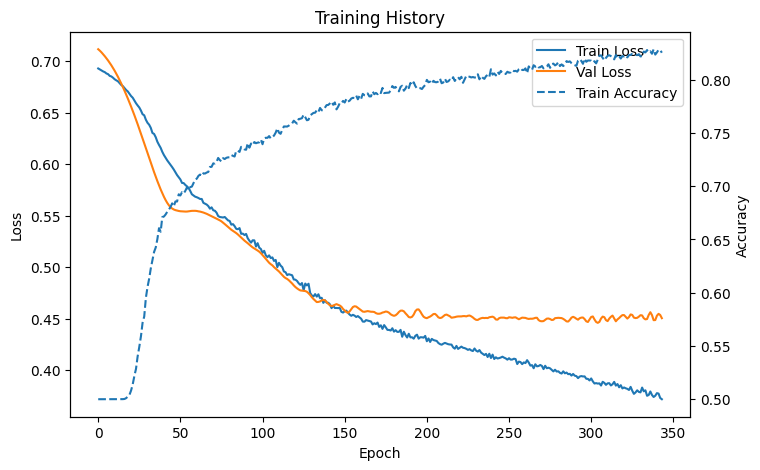

In [300]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(8,5))

# Loss axis
ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# Accuracy axis
ax2 = ax1.twinx()
ax2.plot(train_accuracies, linestyle='--', label="Train Accuracy")
ax2.set_ylabel("Accuracy")

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.title("Training History")
plt.show()

# Predicting the test set result

In [301]:

with torch.no_grad():
    outputs = Classifier(X_test_ten)
    probs = torch.sigmoid(outputs)

In [302]:
preds = (probs >= 0.6).float()
Y_test_ten = Y_test_ten.reshape(-1)

In [303]:
preds = preds.cpu().numpy()

In [304]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test_ten, preds))
print(confusion_matrix(Y_test_ten, preds))

              precision    recall  f1-score   support

         0.0       0.91      0.86      0.89      1607
         1.0       0.53      0.63      0.58       393

    accuracy                           0.82      2000
   macro avg       0.72      0.75      0.73      2000
weighted avg       0.83      0.82      0.83      2000

[[1390  217]
 [ 144  249]]


In [305]:
for t in [0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= t).float()
    print(f"\nThreshold: {t}")
    print(classification_report(Y_test, preds))


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.72      0.82      1607
           1       0.41      0.79      0.54       393

    accuracy                           0.74      2000
   macro avg       0.67      0.76      0.68      2000
weighted avg       0.83      0.74      0.76      2000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      1607
           1       0.46      0.73      0.56       393

    accuracy                           0.78      2000
   macro avg       0.69      0.76      0.71      2000
weighted avg       0.83      0.78      0.79      2000


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1607
           1       0.53      0.63      0.58       393

    accuracy                           0.82      2000
   macro avg       0.72      0.75      0.73      2000
weighted avg       0.83   

In [306]:
# Applying the highest threshold to the model which is 0.7


In [307]:
preds = (probs >= 0.7).float()
Y_test_ten = Y_test_ten.reshape(-1)

In [308]:
preds = preds.cpu().numpy()

In [309]:
print(classification_report(Y_test_ten, preds))
print(confusion_matrix(Y_test_ten, preds))

              precision    recall  f1-score   support

         0.0       0.90      0.91      0.90      1607
         1.0       0.61      0.59      0.60       393

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.75      2000
weighted avg       0.84      0.85      0.84      2000

[[1460  147]
 [ 161  232]]


In [310]:
# To view the updated weights
print(Classifier.Layer1.weight)

Parameter containing:
tensor([[-1.0864e-01, -2.9312e-01,  4.9629e-02, -2.1614e-01,  7.8422e-02,
          2.0490e-01,  1.7625e-02, -3.2408e-01, -2.5670e-01, -2.4128e-02,
         -5.8504e-02, -1.9778e-02],
        [-9.1451e-02,  1.7762e-01, -1.4608e-01,  1.2937e-02, -1.3860e-01,
         -9.1349e-02,  1.9789e-01, -1.2747e-01,  2.0800e-02,  9.5510e-02,
          1.5247e-01, -1.8779e-01],
        [-2.7007e-02, -4.6774e-02, -1.9428e-02,  4.6932e-01,  4.4158e-01,
          9.0595e-03, -3.8043e-03, -1.7342e-02, -2.5749e-01, -4.3423e-02,
         -1.6817e-01, -2.1421e-01],
        [ 3.1201e-01,  4.8861e-02, -1.3130e-01, -2.1186e-01,  4.2175e-01,
          2.7735e-02,  2.0403e-01, -2.2313e-01, -4.2259e-02, -2.9698e-02,
          2.0245e-01,  1.1264e-01],
        [-2.2191e-01, -1.5864e-01,  1.5274e-01, -1.5079e-01,  1.2973e-01,
          8.2935e-03,  2.8627e-01,  1.6123e-01, -7.1727e-02,  9.0845e-02,
         -2.3502e-01, -2.0383e-01],
        [-7.2607e-02, -1.7475e-01,  7.1095e-02, -4.3245e-0

In [311]:
# Improvments
# Apply logistic regression
# Apply random forest
# Apply ROC curve